In [16]:
# copied from /kw18/paper_model_benchmark.ipynb
import pandas as pd
import sklearn

from config.constants import Constants

C = Constants()

In [17]:
sklearn.__version__

'1.8.0'

In [18]:
import xgboost
xgboost.__version__

'3.2.0'

In [19]:
import sys
sys.version

'3.12.12 | packaged by conda-forge | (main, Oct 13 2025, 14:47:45) [Clang 19.1.7 ]'

In [20]:

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw17/20260421_0858_4971_higher_pred_reliability/20260421_0928_ridge_all_individual_tasks_with_task_feature_alpha0.05_all_individual_composite_language_gblu/regression_data.csv")

In [21]:
df.query("composite_language == -1.6813213924202113")

,composite_language,prediction,split_idx,sample_name,task,lit_verb_noun_ratio,lit_subordinate_coordinate_conjunction_ratio,lit_adverb_ratio,lit_noun_ratio,lit_verb_ratio,...,smile_VoicedSegmentsPerSec,smile_MeanUnvoicedSegmentLength,smile_equivalentSoundLevel_dBp,task_journaling,task_picnicScene,dem_age,dem_gender_unified,dem_education_binary,dem_country,dem_socioeconomic
3733,-1.681321,0.347353,9.0,98,cookieTheft,0.055359,0.161317,-0.378957,0.010409,0.209276,...,0.091725,-0.051704,-0.018565,-0.707107,-0.707107,-1.193894,1.23216,0.818412,-0.89168,1.505259
3834,-1.681321,0.179743,9.0,98,journaling,-0.684050,-1.068891,2.287862,-1.082278,-1.900474,...,-1.320362,0.700275,0.157562,1.414214,-0.707107,-1.193894,1.23216,0.818412,-0.89168,1.505259
3935,-1.681321,-0.391998,9.0,98,picnicScene,1.147258,-1.068891,1.798139,-0.728317,1.227178,...,-1.247394,1.885062,-0.414740,-0.707107,1.414214,-1.193894,1.23216,0.818412,-0.89168,1.505259


In [22]:
longitudinal_ids = pd.read_csv(C.LONGITUDINAL_PARTICIPANT_IDS_2024_2026, dtype='str')
longitudinal_sample_names_2024 = longitudinal_ids['2024_study_submission_id'].to_list()
non_longitudinal_sample_names = set(df.sample_name.values) - set(longitudinal_sample_names_2024)
df = df[df.sample_name.isin(non_longitudinal_sample_names)]

In [23]:
#hyperparmeter testing

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor


X = df.drop(columns=["composite_language", "prediction", "split_idx", "sample_name", "task"])
y = df["composite_language"]
groups = df["sample_name"]

# sanity check: all numeric
print(X.dtypes.value_counts())

cv = GroupKFold(n_splits=3)

float64    71
Name: count, dtype: int64


In [24]:
print(*list(X.columns), sep="\n")

lit_verb_noun_ratio
lit_subordinate_coordinate_conjunction_ratio
lit_adverb_ratio
lit_noun_ratio
lit_verb_ratio
lit_pronoun_ratio
lit_personal_pronoun_ratio
lit_determiner_ratio
lit_preposition_ratio
lit_verb_present_participle_ratio
lit_verb_modal_ratio
lit_verb_third_person_singular_ratio
lit_interjection_ratio
lit_NP -> PRP
lit_VP -> VBG
lit_VP -> VBG_PP
lit_VP -> VBD_NP
lit_INTJ -> UH
lit_NP_ratio
lit_VP_ratio
lit_avg_n_words_in_NP
lit_n_words
lit_avg_word_length
lit_words_not_in_dict_ratio
lit_brunets_index
lit_honores_statistic
lit_mattr
lit_NDW-50
lit_flesch_kincaid
lit_avg_distance_between_utterances
lit_prop_utterance_dist_below_05
lit_propositional_density
lit_content_density
sung_frequency_noun
sung_AoA_noun
sung_familiarity_noun
sung_ambiguity_noun
sung_concreteness_noun
pause_fraction_of_pause
pause_mean_pause_duration
pause_std_pause_duration
phon_speech_rate
phon_articulation_rate
smile_F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope
smile_loudness_sma3_percentile20.0
smile_

In [25]:
#X.describe().T[['mean', 'std', 'min', 'max']]
#y.describe().T[['mean', 'std', 'min', 'max']]


In [26]:

# -----------------------------
# Pipelines
# -----------------------------
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

xgb_pipe = Pipeline([
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ))
])

linear_svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVR(
        random_state=42,
        max_iter=20000
    ))
])

rbf_svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel="rbf"))
])




def pred_reliability(y_pred, X):
    cookieTheft = (X['task_picnicScene'] < -0.5) & (X['task_journaling'] < -0.5)
    picnicScene = (X['task_picnicScene'] > 1) & (X['task_journaling'] < -0.5)
    r = np.corrcoef(y_pred[cookieTheft], y_pred[picnicScene])[0, 1]
    return r

def custom_scorer_pred_reliability(estimator, X, y):
    y_pred = estimator.predict(X)
    return pred_reliability(y_pred, X)


scoring = {
    "r2": "r2",
    "reliability": custom_scorer_pred_reliability,
    "mse": "neg_mean_squared_error"
}



# -----------------------------
# Search spaces
# -----------------------------
ridge_params = {
    "model__alpha": np.logspace(-4, 5, 200)
}

linear_svr_params = {
    "model__C": np.logspace(-3, 1, 20),
    "model__epsilon": np.logspace(-3, -0.3, 15),
    "model__loss": ["epsilon_insensitive", "squared_epsilon_insensitive"]
}

rbf_svr_params = {
    "model__C": np.logspace(-2, 2, 20),
    "model__epsilon": np.logspace(-3, -0.3, 15),
    "model__gamma": ["scale", "auto"] + list(np.logspace(-4, -1, 10))
}

xgb_params = {
    "model__n_estimators": [200, 400, 800, 1200],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 7, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.7, 0.9, 1.0],
    "model__reg_alpha": [0, 0.001, 0.01, 0.1, 1],
    "model__reg_lambda": [0.5, 1, 3, 5, 10],
    "model__gamma": [0, 0.01, 0.1, 0.3, 1]
}

# -----------------------------
# Search objects
# -----------------------------
n_iter = 200
ridge_search = RandomizedSearchCV(
    estimator=ridge_pipe,
    param_distributions=ridge_params,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    refit=False,
    random_state=42,
    verbose=2
)

linear_svr_search = RandomizedSearchCV(
    estimator=linear_svr_pipe,
    param_distributions=linear_svr_params,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    refit=False,
    random_state=42,
    verbose=2
)

rbf_svr_search = RandomizedSearchCV(
    estimator=rbf_svr_pipe,
    param_distributions=rbf_svr_params,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    refit=False,
    random_state=42,
    verbose=2
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_params,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    refit=False,
    random_state=42,
    verbose=2
)

# -----------------------------
# Fit
# -----------------------------
searches = {
    "Ridge": ridge_search,
    "SVR linear": linear_svr_search,
    "SVR RBF": rbf_svr_search,
    "XGBoost": xgb_search
}

results = {}
for name, search in searches.items():
    print(f"\n\n\n{name}\n\n\n")
    search.fit(X, y, groups=groups)
    results_df_here = pd.DataFrame(search.cv_results_)
    results_df_here_cols = results_df_here.columns.tolist()
    results_df_here['model'] = name
    results_df_here = results_df_here[['model'] + results_df_here_cols]
    results[name] = results_df_here





Ridge



Fitting 3 folds for each of 200 candidates, totalling 600 fits
[CV] END ................model__alpha=0.00011097524964120722; total time=   0.0s
[CV] END .................model__alpha=0.0001366716356462006; total time=   0.0s
[CV] END ................................model__alpha=0.0001; total time=   0.0s
[CV] END ................model__alpha=0.00012315506032928262; total time=   0.0s
[CV] END ................model__alpha=0.00011097524964120722; total time=   0.0s
[CV] END ................model__alpha=0.00012315506032928262; total time=   0.0s
[CV] END ................model__alpha=0.00012315506032928262; total time=   0.0s
[CV] END ................................model__alpha=0.0001; total time=   0.0s
[CV] END .................model__alpha=0.0001366716356462006; total time=   0.0s
[CV] END ................................model__alpha=0.0001; total time=   0.0s
[CV] END ................model__alpha=0.00011097524964120722; total time=   0.0s
[CV] END .................model__a

/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END model__C=0.12742749857031335, model__epsilon=0.03490254878959581, model__loss=epsilon_insensitive; total time=   0.1s
[CV] END model__C=0.12742749857031335, model__epsilon=0.03490254878959581, model__loss=epsilon_insensitive; total time=   0.1s
[CV] END model__C=0.12742749857031335, model__epsilon=0.002430604433384409, model__loss=epsilon_insensitive; total time=   0.1s
[CV] END model__C=0.001, model__epsilon=0.0037894085316342125, model__loss=epsilon_insensitive; total time=   0.0s
[CV] END model__C=0.001, model__epsilon=0.0037894085316342125, model__loss=epsilon_insensitive; total time=   0.0s
[CV] END model__C=0.12742749857031335, model__epsilon=0.03490254878959581, model__loss=epsilon_insensitive; total time=   0.1s
[CV] END model__C=0.001, model__epsilon=0.0037894085316342125, model__loss=epsilon_insensitive; total time=   0.0s
[CV] END model__C=0.12742749857031335, model__epsilon=0.002430604433384409, model__loss=epsilon_insensitive; total time=   0.1s
[CV] END model__C=

/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END model__C=0.8858667904100823, model__epsilon=0.005907837911587943, model__loss=squared_epsilon_insensitive; total time=   0.0s
[CV] END model__C=0.3359818286283781, model__epsilon=0.0223872113856834, model__loss=epsilon_insensitive; total time=   0.1s
[CV] END model__C=0.3359818286283781, model__epsilon=0.0223872113856834, model__loss=epsilon_insensitive; total time=   0.2s
[CV] END model__C=3.792690190732246, model__epsilon=0.321471781635738, model__loss=squared_epsilon_insensitive; total time=   0.0s
[CV] END model__C=3.792690190732246, model__epsilon=0.321471781635738, model__loss=squared_epsilon_insensitive; total time=   0.0s
[CV] END model__C=3.792690190732246, model__epsilon=0.321471781635738, model__loss=squared_epsilon_insensitive; total time=   0.0s
[CV] END model__C=0.12742749857031335, model__epsilon=0.014359617019622151, model__loss=epsilon_insensitive; total time=   0.1s
[CV] END model__C=0.029763514416313176, model__epsilon=0.5011872336272722, model__loss=epsilon

...

[CV] END model__C=10.0, model__epsilon=0.03490254878959581, model__loss=epsilon_insensitive; total time=   1.8s
[CV] END model__C=0.8858667904100823, model__epsilon=0.321471781635738, model__loss=epsilon_insensitive; total time=   0.3s


/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END model__C=10.0, model__epsilon=0.13226001615907365, model__loss=epsilon_insensitive; total time=   2.0s



SVR RBF



Fitting 3 folds for each of 200 candidates, totalling 600 fits
[CV] END model__C=0.4832930238571752, model__epsilon=0.321471781635738, model__gamma=0.001; total time=   0.8s
[CV] END model__C=0.4832930238571752, model__epsilon=0.321471781635738, model__gamma=0.001; total time=   0.8s
[CV] END model__C=0.4832930238571752, model__epsilon=0.321471781635738, model__gamma=0.001; total time=   0.9s
[CV] END model__C=100.0, model__epsilon=0.20619860095022213, model__gamma=0.1; total time=   0.8s
[CV] END model__C=100.0, model__epsilon=0.20619860095022213, model__gamma=0.1; total time=   0.9s
[CV] END model__C=0.29763514416313175, model__epsilon=0.014359617019622151, model__gamma=0.01; total time=   1.0s
[CV] END model__C=0.29763514416313175, model__epsilon=0.014359617019622151, model__gamma=0.01; total time=   1.2s
[CV] END model__C=100.0, model__epsilon=0.084834289824

/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__colsample_bytree=1.0, model__gamma=0.01, model__learning_rate=0.03, model__max_depth=2, model__min_child_weight=3, model__n_estimators=400, model__reg_alpha=0, model__reg_lambda=1, model__subsample=0.8; total time=   0.4s
[CV] END model__colsample_bytree=0.9, model__gamma=0.01, model__learning_rate=0.1, model__max_depth=2, model__min_child_weight=7, model__n_estimators=400, model__reg_alpha=0.1, model__reg_lambda=5, model__subsample=1.0; total time=   0.4s
[CV] END model__colsample_bytree=1.0, model__gamma=0.3, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=5, model__n_estimators=400, model__reg_alpha=0, model__reg_lambda=5, model__subsample=0.8; total time=   0.8s
[CV] END model__colsample_bytree=0.9, model__gamma=0.01, model__learning_rate=0.1, model__max_depth=2, model__min_child_weight=7, model__n_estimators=400, model__reg_alpha=0.1, model__reg_lambda=5, model__subsample=1.0; total time=   0.5s
[CV] END model__colsample_bytree=0.9, model__gam

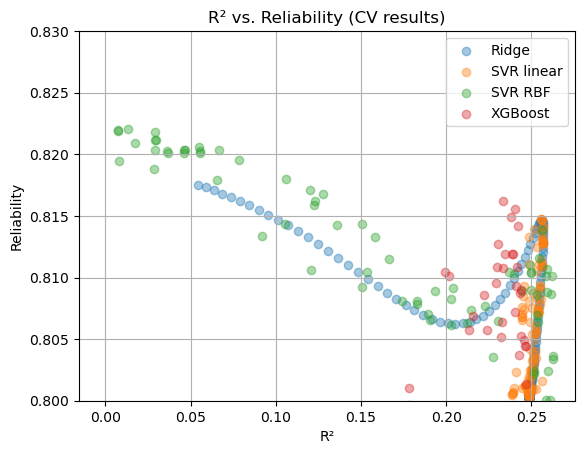

In [27]:
import matplotlib.pyplot as plt
plt.figure()


for name in searches:
    plot_df = results[name]


    plt.scatter(
        plot_df["mean_test_r2"],
        plot_df["mean_test_reliability"],
        alpha=0.4,
        label=name,
    )


plt.legend()
plt.xlabel("R²")
plt.ylabel("Reliability")
plt.title("R² vs. Reliability (CV results)")

#plt.xlim(0.25, 0.27)
plt.ylim(0.8, 0.83)

plt.grid(True)
plt.show()

In [28]:
# estimate MDC based on interpolation of the simulation results

import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

df = pd.read_parquet('mdc_points_for_estimator.parquet')
pts = df[['regression_r2', 'sample_biomarker_reliability']].values
vals = df['mdc_latent_space'].values
linear_interp = LinearNDInterpolator(pts, vals)
nearest_interp = NearestNDInterpolator(pts, vals)

def estimate_mdc(r2, reliability):
    out = linear_interp(r2, reliability)
    if np.ndim(out) == 0:
        return float(out) if np.isfinite(out) else float(nearest_interp(r2, reliability))
    mask = ~np.isfinite(out)
    out[mask] = nearest_interp(np.array(r2)[mask], np.array(reliability)[mask])
    return out

In [41]:
alpha = 1.5
beta = -1
results_combined = pd.concat(results)
# custom ad-hoc sorting
results_combined['sorting'] = alpha * results_combined['mean_test_reliability'] + beta * (1-results_combined['mean_test_r2'])

results_combined['estimated_mdc1'] = 1.45 * np.sqrt((1-results_combined['mean_test_reliability'])/results_combined['mean_test_r2'])

results_combined['estimated_mdc'] = 1.91 * np.sqrt(2*0.91*results_combined['mean_test_reliability']* (1-results_combined['mean_test_reliability'])/results_combined['mean_test_r2'])

results_combined['estimated_mdc_data'] = results_combined.apply(lambda row: estimate_mdc(row['mean_test_r2'], row['mean_test_reliability']), axis=1)

results_combined = results_combined.sort_values('estimated_mdc_data', ascending=True)
results_compact = results_combined[['mean_test_r2', 'mean_test_reliability', 'model', 'params'] + results_combined.columns.tolist()]
results_compact.to_csv("benchmarking_results.csv")
results_compact

/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jheitz/miniconda3/envs/phd_new/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


mean_test_r2  mean_test_reliability    model  \
SVR RBF 190      0.262399               0.810146  SVR RBF   
Ridge   145      0.256881               0.814380    Ridge   
        146      0.256708               0.814517    Ridge   
        144      0.256989               0.814198    Ridge   
        147      0.256463               0.814605    Ridge   
...                   ...                    ...      ...   
SVR RBF 70       0.003313               0.438306  SVR RBF   
        32      -0.000714               0.419127  SVR RBF   
        122     -0.002108               0.429912  SVR RBF   
        81      -0.000886               0.430341  SVR RBF   
        97       0.000864               0.435547  SVR RBF   

                                                        params    model  \
SVR RBF 190  {'model__gamma': 0.001, 'model__epsilon': 0.32...  SVR RBF   
Ridge   145               {'model__alpha': 361.23426997094305}    Ridge   
        146                {'model__alpha': 400.8806328898465}    Ridge   
        144               {'model__alpha': 325.50885998350566}    Ridge   
        147               {'model__alpha': 444.87828311275854}    Ridge   
...                                                        ...      ...   
SVR RBF 70   {'model__gamma': 0.1, 'model__epsilon': 0.0143...  SVR RBF   
        32   {'model__gamma': 0.1, 'model__epsilon': 0.5011...  SVR RBF   
        122  {'model__gamma': 0.1, 'model__epsilon': 0.0544...  SVR RBF   
        81   {'model__gamma': 0.1, 'model__epsilon': 0.0143...  SVR RBF   
        97   {'model__gamma': 0.1, 'model__epsilon': 0.001,...  SVR RBF   

             mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
SVR RBF 190       0.284041      0.032611         0.613916        0.014719   
Ridge   145       0.009081      0.001666         0.005903        0.002827   
        146       0.012851      0.005479         0.004072        0.000272   
        144       0.006427      0.000291         0.003658        0.000058   
        147       0.006388      0.000132         0.004318        0.000918   
...                    ...           ...              ...             ...   
SVR RBF 70        0.617199      0.002290         1.511860        0.026854   
        32        0.284803      0.018019         0.548296        0.074787   
        122       0.547452      0.020727         1.271135        0.010292   
        81        0.376318      0.008232         0.861890        0.013314   
        97        0.341832      0.025336         0.860011        0.010704   

             param_model__alpha  ... param_model__reg_alpha  \
SVR RBF 190                 NaN  ...                    NaN   
Ridge   145          361.234270  ...                    NaN   
        146          400.880633  ...                    NaN   
        144          325.508860  ...                    NaN   
        147          444.878283  ...                    NaN   
...                         ...  ...                    ...   
SVR RBF 70                  NaN  ...                    NaN   
        32                  NaN  ...                    NaN   
        122                 NaN  ...                    NaN   
        81                  NaN  ...                    NaN   
        97                  NaN  ...                    NaN   

             param_model__n_estimators  param_model__min_child_weight  \
SVR RBF 190                        NaN                            NaN   
Ridge   145                        NaN                            NaN   
        146                        NaN                            NaN   
        144                        NaN                            NaN   
        147                        NaN                            NaN   
...                                ...                            ...   
SVR RBF 70                         NaN                            NaN   
        32                         NaN                            NaN   
        122                        NaN  

In [67]:
# best configuration per model
paper_export = results_combined[['mean_test_r2', 'mean_test_reliability', 'model', 'params', 'estimated_mdc_data']].reset_index(drop=True)
best_idx = paper_export.groupby("model")['estimated_mdc_data'].idxmin()
best_per_model = paper_export.loc[best_idx].reset_index(drop=True).sort_values(by='estimated_mdc_data', ascending=True)[['model', 'params']]
def format_val(val):
    return val
    if isinstance(val, float):
        return f"{val:.3f}"
    return val
def format_params(params: dict):
    params_replaced = {k.replace("model__", ""): format_val(val) for k, val in params.items()}
    params_str = ", ".join([f"{k}: {v}" for k, v in params_replaced.items()])
    return params_str
best_per_model['params'] = best_per_model['params'].apply(format_params)
best_per_model = best_per_model.rename(columns={'params': 'Hyperparameters', 'model': 'Model family'})

In [69]:
print(best_per_model.to_latex(index=False,
                        label="tab:hyperparameters",
                        caption="Best hyperparameters for each model family.",
                      column_format="lp{10cm}"
 ).replace("_", "\\_"))

\begin{table}
\caption{Best hyperparameters for each model family.}
\label{tab:hyperparameters}
\begin{tabular}{lp{10cm}}
\toprule
Model family & Hyperparameters \\
\midrule
SVR RBF & gamma: 0.001, epsilon: 0.321471781635738, C: 3.359818286283781 \\
Ridge & alpha: 361.23426997094305 \\
SVR linear & loss: squared\_epsilon\_insensitive, epsilon: 0.0015590395868560912, C: 0.001623776739188721 \\
XGBoost & subsample: 0.8, reg\_lambda: 1, reg\_alpha: 0.01, n\_estimators: 400, min\_child\_weight: 1, max\_depth: 4, learning\_rate: 0.01, gamma: 1, colsample\_bytree: 0.7 \\
\bottomrule
\end{tabular}
\end{table}

